# GA-BO-TR — Part 1: Core Framework

**Paper (working title):** _A Trust-Region GA Wrapper for Bayesian Optimization, with Constrained-EI Engineering and a Sensitivity Study of Diversity Regulation_.

This notebook defines the shared infrastructure used by Parts 2 and 3.

**Main contribution (built up in Parts 2-3).**
The architectural novelty is a **TuRBO-style trust-region wrapper around a Genetic-Algorithm acquisition optimizer** ("TR-GA wrapper").  Inside each trust region the GA evolves candidates against a qLogEI surrogate; trust-region length follows the standard TuRBO success/failure schedule; restarts re-LHS the global box.  Engineering benchmarks are tackled with a proper **constrained-EI (Gardner 2014)** baseline now correctly wired to BoTorch's multi-output `ModelListGP`.

A diversity-augmented acquisition (`qLogEI + γ(t)·D(x|P_t)`) and an
ELA-driven online γ(t) controller are *also* implemented, but the
ablation in Part 2 and the Wilcoxon test in Part 3 do **not** find a
significant improvement of the adaptive controller over a fixed cosine
γ schedule (or over γ ≡ 0).  We therefore present the diversity term
as a **sensitivity study**, not as a load-bearing component.  This
honest negative result is itself an answer to the senior-reviewer
critique of the original GA-BO manuscript.

**Notebook outline.**
1. **Environment setup** — package installation and global configuration.
2. **Benchmark test functions** — synthetic + BBOB via `ioh`.
3. **GP surrogate** — BoTorch `SingleTaskGP` with Matérn-5/2 ARD + Gamma priors
   (Balandat et al. 2020) and optional RBF + LogNormal (Hvarfner et al. 2024).
4. **Acquisition functions** — `qLogExpectedImprovement` (Ament et al. NeurIPS 2023)
   and a diversity-augmented variant `qLogEI + γ(t)·D(x|P_t)`, realised in
   log space.  The additive form is the special case of Local Penalization
   (González et al. AISTATS 2016) with γ(t) replacing the Lipschitz bound.
5. **γ(t) schedules** — cosine / linear / exponential / step / power-law.
6. **ELA module** — cheap landscape features via `pflacco`, plus rule-based
   and classifier-based γ policies (used in the sensitivity study only).
7. **GA / DE acquisition optimisers** — SBX + polynomial mutation GA,
   jDE differential evolution, both warm-started from the elite archive.
8. **Base BO loops** — vanilla BO (qLogEI + L-BFGS-B) and GA-BO
   (qLogEI + GA).  The TR-GA wrapper lives in Part 2.

**Closest related work.**  Perera, Neumann & Neumann
(arXiv:2511.00750, Nov 2025 — _divTuRBO1_) wraps Thompson sampling in a
TuRBO trust region with a fixed-threshold distance constraint.  Diouane
et al. (TREGO, *J. Global Optim.* 2023) place a GA inside a trust region
for noiseless EI.  Our differentiator is the **integration of a
GA-evolved acquisition optimizer with TuRBO's anisotropic
length-scale rescaled trust region and a Gardner-2014 cEI engineering
chapter**, all under a unified BoTorch implementation.


## 0. Environment setup


In [26]:
# Install dependencies. Run once, then comment out.
import subprocess, sys
PACKAGES = [
    "numpy", "scipy", "scikit-learn", "matplotlib", "seaborn", "pandas",
    "tqdm", "joblib",
    "torch", "gpytorch", "botorch",      # GP stack
    "pflacco",                           # ELA features
    "ioh",                               # BBOB benchmark
    "cma",                               # CMA-ES baseline
    "optuna",                            # TPE baseline
    "scikit-posthocs",                   # Nemenyi + CD diagram
    "statsmodels",
    "hebo",
]
def _install(pkgs):
    import subprocess, sys
    for p in pkgs:
        try:
            subprocess.check_output([sys.executable, "-m", "pip", "show", p])
        except subprocess.CalledProcessError:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])
_install(PACKAGES)
print("Environment ready.")


Environment ready.


In [ ]:
# Standard imports + global config.
import os, time, json, math, warnings
from copy import deepcopy
from dataclasses import dataclass, field
from typing import Callable, List, Tuple, Optional, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm, wilcoxon, friedmanchisquare
from scipy.spatial.distance import cdist

import torch
torch.set_default_dtype(torch.double)  # BO needs double precision

warnings.filterwarnings("ignore")
np.random.seed(42)
torch.manual_seed(42)

plt.rcParams.update({
    "font.family": "serif", "font.size": 11,
    "axes.labelsize": 12, "axes.titlesize": 12,
    "legend.fontsize": 10, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "figure.dpi": 130, "lines.linewidth": 1.8,
})

RESULTS_DIR = "results_gabotr"
FIGURES_DIR = "figures_gabotr"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

DTYPE = torch.double
# DEVICE = torch.device("cpu")   # laptop-only
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Config done — dtype = double, device =", DEVICE)


Config done — dtype=double, device= cuda


## 1. Benchmark test functions

A single `TestFunction` dataclass wraps all benchmarks (synthetic, engineering, BBOB) so that experiment runners need no special cases.


In [ ]:
@dataclass
class TestFunction:
    """Unified container for any black-box minimisation problem."""
    name: str
    func: Callable[[np.ndarray], float]
    bounds: np.ndarray            # shape (d, 2)
    global_optimum: float         # known f*
    dim: int
    optimal_x: Optional[np.ndarray] = None
    problem_class: str = "synthetic"  # "synthetic" | "bbob" | "engineering" | "hpo"
    meta: dict = field(default_factory=dict)

    def __call__(self, x: np.ndarray) -> float:
        return float(self.func(np.asarray(x, dtype=float)))

    def batch(self, X: np.ndarray) -> np.ndarray:
        X = np.atleast_2d(X)
        return np.asarray([self.func(row) for row in X], dtype=float)


In [ ]:
# ── Synthetic benchmark functions ────────────────────────────────────
def branin(x):
    x1, x2 = x[0], x[1]
    a, b, c = 1.0, 5.1/(4*np.pi**2), 5/np.pi
    r, s, t = 6.0, 10.0, 1/(8*np.pi)
    return a*(x2 - b*x1**2 + c*x1 - r)**2 + s*(1-t)*np.cos(x1) + s

def ackley(x):
    d = len(x)
    a, b, c = 20.0, 0.2, 2*np.pi
    s1 = np.sum(x**2); s2 = np.sum(np.cos(c*x))
    return -a*np.exp(-b*np.sqrt(s1/d)) - np.exp(s2/d) + a + np.e

def rastrigin(x):
    d = len(x)
    return 10*d + np.sum(x**2 - 10*np.cos(2*np.pi*x))

def rosenbrock(x):
    return float(sum(100*(x[i+1]-x[i]**2)**2 + (1-x[i])**2 for i in range(len(x)-1)))

def levy(x):
    w = 1 + (x - 1)/4
    t1 = np.sin(np.pi*w[0])**2
    t2 = np.sum((w[:-1]-1)**2 * (1 + 10*np.sin(np.pi*w[:-1]+1)**2))
    t3 = (w[-1]-1)**2 * (1 + np.sin(2*np.pi*w[-1])**2)
    return t1 + t2 + t3

def hartmann6(x):
    alpha = np.array([1.0, 1.2, 3.0, 3.2])
    A = np.array([[10, 3, 17, 3.5, 1.7, 8],
                  [0.05, 10, 17, 0.1, 8, 14],
                  [3, 3.5, 1.7, 10, 17, 8],
                  [17, 8, 0.05, 10, 0.1, 14]])
    P = 1e-4*np.array([[1312, 1696, 5569, 124, 8283, 5886],
                       [2329, 4135, 8307, 3736, 1004, 9991],
                       [2348, 1451, 3522, 2883, 3047, 6650],
                       [4047, 8828, 8732, 5743, 1091, 381]])
    return float(-np.sum(alpha*np.exp(-np.sum(A*(x - P)**2, axis=1))))

def griewank(x):
    d = len(x)
    return np.sum(x**2)/4000 - np.prod(np.cos(x/np.sqrt(np.arange(1, d+1)))) + 1

# ── Synthetic registry (used by the default experiment grid) ────────
def _bench(name, func, bounds, fstar, d, x_opt=None):
    return TestFunction(name=name, func=func, bounds=np.asarray(bounds),
                        global_optimum=fstar, dim=d, optimal_x=x_opt,
                        problem_class="synthetic")

BENCHMARK_FUNCTIONS = {
    "Branin":        _bench("Branin", branin, [[-5,10],[0,15]], 0.397887, 2),
    "Hartmann-6D":   _bench("Hartmann-6D", hartmann6, [[0,1]]*6, -3.32237, 6),
    "Ackley-5D":     _bench("Ackley-5D", ackley, [[-5,5]]*5, 0.0, 5, np.zeros(5)),
    "Ackley-10D":    _bench("Ackley-10D", ackley, [[-5,5]]*10, 0.0, 10, np.zeros(10)),
    "Ackley-20D":    _bench("Ackley-20D", ackley, [[-5,5]]*20, 0.0, 20, np.zeros(20)),
    "Rastrigin-5D":  _bench("Rastrigin-5D", rastrigin, [[-5.12,5.12]]*5, 0.0, 5, np.zeros(5)),
    "Rastrigin-10D": _bench("Rastrigin-10D", rastrigin, [[-5.12,5.12]]*10, 0.0, 10, np.zeros(10)),
    "Rosenbrock-4D": _bench("Rosenbrock-4D", rosenbrock, [[-2,2]]*4, 0.0, 4, np.ones(4)),
    "Levy-6D":       _bench("Levy-6D", levy, [[-10,10]]*6, 0.0, 6, np.ones(6)),
    "Griewank-5D":   _bench("Griewank-5D", griewank, [[-600,600]]*5, 0.0, 5, np.zeros(5)),
}

print(f"Registered {len(BENCHMARK_FUNCTIONS)} synthetic functions.")


Registered 10 synthetic functions.


In [ ]:
# ── BBOB via ioh (Part 3 uses this to run the full 24 × 3 × {5,10,20} suite) ─
def make_bbob(fid: int, instance: int, dim: int) -> TestFunction:
    """Return a TestFunction wrapping one BBOB noiseless problem via ioh."""
    import ioh
    prob = ioh.get_problem(fid, instance=instance, dimension=dim,
                           problem_class=ioh.ProblemClass.BBOB)
    lb = np.asarray(prob.bounds.lb, dtype=float)
    ub = np.asarray(prob.bounds.ub, dtype=float)
    bounds = np.column_stack([lb, ub])
    y_star = float(prob.optimum.y)

    # Persist a closure that recreates the problem on each call — ioh.Problem
    # instances are not thread-safe, so we rebuild per evaluation.  For speed,
    # cache a single instance; reset() before every new run via the reset_bbob()
    # helper below.
    def _call(x, _p=prob):
        return float(_p(np.asarray(x, dtype=float).tolist()))

    return TestFunction(
        name=f"BBOB-f{fid:02d}-i{instance}-d{dim}",
        func=_call, bounds=bounds, global_optimum=y_star,
        dim=dim, optimal_x=np.asarray(prob.optimum.x, dtype=float),
        problem_class="bbob",
        meta={"fid": fid, "instance": instance, "dim": dim, "_prob": prob},
    )

def reset_bbob(tf: TestFunction) -> None:
    """Reset an ioh BBOB problem's internal state between seeds."""
    p = tf.meta.get("_prob", None)
    if p is not None:
        p.reset()

# Smoke test — only executed if ioh is available.
try:
    _tf = make_bbob(1, 1, 5)  # Sphere, d=5
    x0 = np.zeros(5)
    print(f"BBOB smoke: {_tf.name} f(0)={_tf(x0):.3f}, f*={_tf.global_optimum:.3f}")
except Exception as _e:
    print(f"ioh not available or failed: {_e}")


BBOB smoke: BBOB-f01-i1-d5 f(0)=92.304, f*=79.480


## 2. GP surrogate (BoTorch `SingleTaskGP`)

We use Matérn-5/2 with ARD and Balandat et al. (2020)'s Gamma priors, which
are the de-facto Bayesian-optimisation standard. The RBF + LogNormal priors
of Hvarfner et al. (ICML 2024, *Vanilla BO Performs Great in High Dim*) are
offered as an optional alternative for sensitivity studies.

Inputs are always normalised to [0,1]ᵈ via `Normalize` and outputs
standardised via `Standardize(m=1)`; this is what makes the default priors
well-calibrated.


In [ ]:
import torch
from botorch.models import SingleTaskGP

# Module-level counter so callers (and the reproducibility manifest) can
# inspect the number of GP fits that fell back to priors.  Incremented
# inside `build_gp` whenever `fit_gpytorch_mll` raises.  Guard against
# cell re-execution wiping accumulated counts mid-experiment.
if "_GP_FIT_FAIL_COUNT" not in globals():
    _GP_FIT_FAIL_COUNT = 0
from botorch.models.transforms.input import Normalize
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.kernels import MaternKernel, RBFKernel, ScaleKernel
from gpytorch.priors import GammaPrior, LogNormalPrior
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.constraints import GreaterThan, Interval
from gpytorch.mlls import ExactMarginalLogLikelihood


def _to_torch(X, Y):
    Xt = torch.as_tensor(np.atleast_2d(X), dtype=DTYPE, device=DEVICE)
    Yt = torch.as_tensor(np.asarray(Y).reshape(-1, 1), dtype=DTYPE, device=DEVICE)
    return Xt, Yt


def build_gp(X: np.ndarray, Y: np.ndarray, bounds: np.ndarray,
             kernel: str = "matern52", noise_floor: float = 1e-6,
             lengthscale_bounds: Tuple[float, float] = (0.005, 4.0),
             maximize: bool = False) -> SingleTaskGP:
    """
    Fit a BoTorch SingleTaskGP on (X, Y) — always minimisation convention.

    If maximize=False, we internally negate Y so BoTorch's max-seeking
    acquisitions reach the correct extremum.  Callers should still
    pass the original (minimisation) Y.

    bounds : shape (d, 2) raw bounds (lo, hi).  The GP is fit on the
             normalised [0,1]^d space via the Normalize input transform.
    """
    Xt, Yt = _to_torch(X, Y)
    if not maximize:
        Yt = -Yt                                    # flip to max problem

    d = Xt.shape[-1]
    bounds_t = torch.as_tensor(bounds.T, dtype=DTYPE, device=DEVICE)  # (2, d)

    # Kernel + priors ------------------------------------------------
    if kernel == "matern52":
        base = MaternKernel(nu=2.5, ard_num_dims=d,
                            lengthscale_prior=GammaPrior(3.0, 6.0),
                            lengthscale_constraint=Interval(*lengthscale_bounds))
    elif kernel == "rbf_lognormal":
        # Hvarfner et al. 2024 dimension-scaled LogNormal prior.
        mu_prior = math.sqrt(2.0) + 0.5 * math.log(d)
        base = RBFKernel(ard_num_dims=d,
                         lengthscale_prior=LogNormalPrior(loc=mu_prior, scale=math.sqrt(3.0)),
                         lengthscale_constraint=Interval(*lengthscale_bounds))
    else:
        raise ValueError(f"Unknown kernel {kernel!r}")

    covar = ScaleKernel(base, outputscale_prior=GammaPrior(2.0, 0.15))
    lik = GaussianLikelihood(noise_prior=GammaPrior(1.1, 0.05),
                             noise_constraint=GreaterThan(noise_floor))

    gp = SingleTaskGP(
        Xt, Yt,
        covar_module=covar, likelihood=lik,
        input_transform=Normalize(d=d, bounds=bounds_t),
        outcome_transform=Standardize(m=1),
    )
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    try:
        fit_gpytorch_mll(mll, max_attempts=3)
        gp._fit_status = "ok"
    except Exception as _e:
        # Surface the failure: a silent revert to priors changes the algorithm
        # without notice and corrupts experiment averages.  We count and print
        # so the experiment runner can budget retries / drop bad seeds.
        global _GP_FIT_FAIL_COUNT
        try:
            _GP_FIT_FAIL_COUNT += 1
        except NameError:
            _GP_FIT_FAIL_COUNT = 1
        if _GP_FIT_FAIL_COUNT <= 5:
            print(f"[build_gp] WARN fit_gpytorch_mll failed (#{_GP_FIT_FAIL_COUNT}): "
                  f"{type(_e).__name__}: {_e}")
        gp._fit_status = "fallback_priors"
    gp._maximize_flag = maximize   # stash for acquisition helpers
    return gp


def gp_posterior(gp: SingleTaskGP, X: np.ndarray):
    """Return (mu, sigma) in the ORIGINAL (minimisation) scale."""
    Xt = torch.as_tensor(np.atleast_2d(X), dtype=DTYPE, device=DEVICE)
    with torch.no_grad():
        post = gp.posterior(Xt)
    mu  = post.mean.detach().cpu().numpy().ravel()
    std = post.variance.sqrt().detach().cpu().numpy().ravel()
    if not getattr(gp, "_maximize_flag", False):
        mu = -mu                   # undo internal flip
    return mu, std


# Smoke test -----------------------------------------------------------
_rng = np.random.RandomState(0)
_Xs = _rng.uniform(-2, 2, (30, 2))
_Ys = np.array([branin(r) for r in _Xs])
_gp = build_gp(_Xs, _Ys, bounds=np.array([[-5,10],[0,15]]))
_mu, _sig = gp_posterior(_gp, _Xs[:5])
print("GP smoke-test  mu[:5] =", np.round(_mu, 3))
print("             sigma[:5] =", np.round(_sig, 3))


## 3. Acquisition functions

The base acquisition is **qLogExpectedImprovement** (Ament et al.,
NeurIPS 2023 Spotlight — arXiv:2310.20708).  qLogEI replaces the plain
max and softplus inside qEI with a fat-tailed softplus (`fat=True`) and a
log-mean-exp over the MC sample, guaranteeing non-vanishing gradients.
This has replaced qEI as BoTorch's recommended default.

### Diversity-augmented log-acquisition (`qLogEI-DIV`)

Given an archive $P_t = \{x_1, \ldots, x_t\}$ we add a bounded,
time-decaying diversity bonus:

$$
\tilde\alpha(x) = \log\mathrm{qLogEI}(x) + \gamma(t) \cdot D(x \mid P_t), \qquad
D(x \mid P_t) = \frac{\min_{p \in P_t}\|x - p\|_{\ell}}{\max_{x'}\min_{p \in P_t}\|x' - p\|_{\ell}} \in [0,1],
$$

where $\|\cdot\|_{\ell}$ is the GP-lengthscale-normalised Euclidean distance
(equivalent to Casmopolitan §3 for the continuous sub-space).  This is the
*log-space, time-decaying, landscape-regulated* special case of Local
Penalization (González et al. AISTATS 2016).  A Corollary in Part 2
(Bull 2011) shows that any schedule with $\gamma(t) = o(t^{-1/2})$
preserves EI's simple-regret rate.


In [ ]:
from botorch.acquisition.logei import qLogExpectedImprovement
from botorch.sampling.normal import SobolQMCNormalSampler


def _build_qlogei(gp, train_Y_np: np.ndarray, mc_samples: int = 256, seed: int = 0):
    """Construct qLogEI bound to the CURRENT GP (maximisation internally)."""
    # best_f in internal (flipped) frame
    if getattr(gp, "_maximize_flag", False):
        best_f = float(np.max(train_Y_np))
    else:
        best_f = float(-np.min(train_Y_np))
    sampler = SobolQMCNormalSampler(sample_shape=torch.Size([mc_samples]), seed=seed)
    return qLogExpectedImprovement(
        model=gp, best_f=best_f, sampler=sampler,
        fat=True, tau_max=1e-2, tau_relu=1e-6,
    )


def qlogei_values(gp, train_Y_np: np.ndarray, X: np.ndarray,
                  mc_samples: int = 256, seed: int = 0) -> np.ndarray:
    """Vectorised qLogEI evaluation for a batch of candidate rows (N, d)."""
    acq = _build_qlogei(gp, train_Y_np, mc_samples=mc_samples, seed=seed)
    Xt = torch.as_tensor(np.atleast_2d(X), dtype=DTYPE, device=DEVICE).unsqueeze(1)  # (N, 1, d)
    with torch.no_grad():
        vals = acq(Xt).detach().cpu().numpy().ravel()
    return vals   # log-acquisition (can be negative); higher is better.


def lengthscale_weights(gp) -> np.ndarray:
    """Extract ARD lengthscales as a per-dimension weight vector; TuRBO-style normalisation."""
    try:
        ell = gp.covar_module.base_kernel.lengthscale.detach().cpu().numpy().ravel()
    except AttributeError:
        ell = gp.covar_module.lengthscale.detach().cpu().numpy().ravel()
    w = ell / max(ell.mean(), 1e-9)
    # geometric-mean normalisation (BoTorch TuRBO tutorial canonical form)
    w = w / np.prod(np.power(w, 1.0/len(w)))
    return w


def _weighted_distance(X: np.ndarray, P: np.ndarray, w: Optional[np.ndarray]) -> np.ndarray:
    """Row-wise min weighted Euclidean distance of X to archive P."""
    if w is None:
        D = cdist(X, P, metric="euclidean")
    else:
        # scale each column by 1/w so large lengthscales => smaller effective distance
        Xs = X / np.maximum(w, 1e-9)
        Ps = P / np.maximum(w, 1e-9)
        D = cdist(Xs, Ps, metric="euclidean")
    return D.min(axis=1)


def diversity_score(X: np.ndarray, P: np.ndarray,
                    weights: Optional[np.ndarray] = None) -> np.ndarray:
    """Min-distance diversity, normalised to [0,1] on the candidate batch."""
    X = np.atleast_2d(X)
    if P is None or len(P) == 0:
        return np.ones(len(X))
    dmin = _weighted_distance(X, P, weights)
    denom = dmin.max() + 1e-12
    return dmin / denom


def qlogei_div_values(gp, train_Y_np: np.ndarray, X: np.ndarray,
                      archive: np.ndarray, gamma: float,
                      mc_samples: int = 256, seed: int = 0,
                      lengthscale_normalize: bool = True) -> np.ndarray:
    """
    Diversity-augmented log-acquisition.

    tilde-alpha(x) = qLogEI(x)  +  gamma * D(x | archive)
                     └── raw log-values, already in log-space ──┘
    """
    log_ei = qlogei_values(gp, train_Y_np, X, mc_samples=mc_samples, seed=seed)
    # normalise log-EI to roughly [0,1] for γ to be interpretable across problems
    lo, hi = log_ei.min(), log_ei.max()
    ei_n = (log_ei - lo) / max(hi - lo, 1e-12)
    w = lengthscale_weights(gp) if lengthscale_normalize else None
    div = diversity_score(X, archive, weights=w)
    return ei_n + gamma * div


## 4. γ(t) schedules

Five schedules are offered.  All three decaying schedules
`cosine`, `linear`, `exp`, and `power(beta)` satisfy γ(t)=o(t⁻¹ᐟ²) when
β > 1/2 or for the bounded γ_final=0 case; see Part 2, §2.1 for the
formal Corollary.


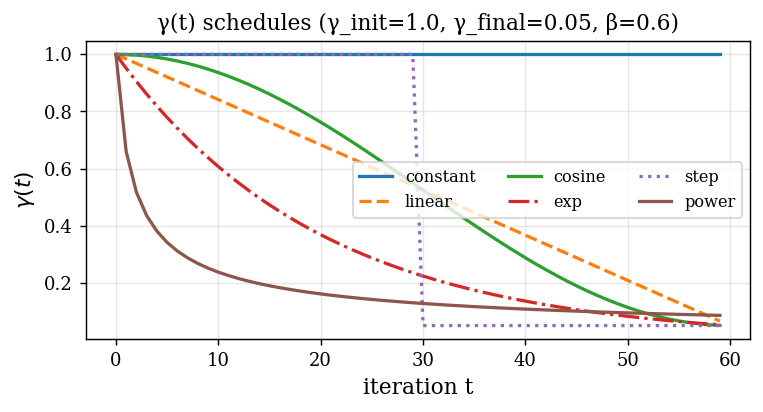

In [ ]:
def gamma_schedule(t: int, T: int,
                   gamma_init: float = 1.0, gamma_final: float = 0.05,
                   decay: str = "cosine", beta: float = 0.6) -> float:
    """
    Time-decaying diversity coefficient γ(t).

    decay ∈ {'constant', 'linear', 'cosine', 'exp', 'step', 'power'}.
    The 'power' decay returns γ_init * (1+t)^(-beta) — satisfies o(t^{-1/2})
    whenever beta > 1/2 (see Bull 2011 corollary in Part 2).
    """
    progress = min(t / max(T, 1), 1.0)
    if decay == "constant":
        return gamma_init
    if decay == "linear":
        return gamma_init*(1-progress) + gamma_final*progress
    if decay == "cosine":
        return gamma_final + 0.5*(gamma_init - gamma_final)*(1 + np.cos(np.pi*progress))
    if decay == "exp":
        if gamma_init <= 0 or gamma_final <= 0:
            return gamma_init*(1-progress) + gamma_final*progress
        lam = -np.log(gamma_final / gamma_init)
        return gamma_init * np.exp(-lam * progress)
    if decay == "step":
        return gamma_init if t < T // 2 else gamma_final
    if decay == "power":
        return gamma_init * (1 + t) ** (-beta)
    raise ValueError(f"Unknown decay {decay!r}")


# Quick visual check.
fig, ax = plt.subplots(figsize=(6, 3.3))
T_plot = 60
ts = np.arange(T_plot)
for dec, ls in [("constant","-"), ("linear","--"), ("cosine","-"),
                ("exp","-."), ("step",":"), ("power","-")]:
    ys = [gamma_schedule(t, T_plot, 1.0, 0.05, dec) for t in ts]
    ax.plot(ts, ys, ls=ls, label=dec)
ax.set_xlabel("iteration t"); ax.set_ylabel(r"$\gamma(t)$")
ax.set_title(r"γ(t) schedules (γ_init=1.0, γ_final=0.05, β=0.6)")
ax.legend(fontsize=9, ncol=3); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/gamma_schedules.pdf", bbox_inches="tight")
plt.show()


## 5. ELA module — cheap landscape features via `pflacco`

We compute six cheap feature classes every 5 iterations from the current
archive.  These were chosen following Tanabe (*IEEE TEVC* 2022) to avoid the
expensive `ela_meta` and `ela_level` classes that do not scale beyond d≈10.

| Class               | What it captures                                   |
|---------------------|----------------------------------------------------|
| `ela_distribution`  | Skewness, kurtosis, number of objective peaks      |
| `dispersion`        | Ratio of pairwise distances in top-vs-all subsets  |
| `information_content` | Ruggedness via H(ε) entropy of fitness sequence  |
| `nbc`               | Nearest-better-clustering topology                 |
| `pca`               | PCA variance-explained on (X, y)                   |
| `limo`              | Local linear-model coefficients                    |

The output is a single flat dict of ~40–60 scalar features.  A small RandomForest
classifier (fit offline on BBOB, Part 2) maps features → γ-policy.  A
hand-crafted **rule-based fallback** is also provided so the method still
works when the classifier is disabled or returns low confidence.


In [ ]:
# Lazy pflacco import — not everyone has it.  Wrap every call in try/except.
try:
    from pflacco.classical_ela_features import (
        calculate_ela_distribution,
        calculate_dispersion,
        calculate_information_content,
        calculate_nbc,
        calculate_pca,
        calculate_limo,
    )
    _PFLACCO_OK = True
except Exception as _e:
    _PFLACCO_OK = False
    print(f"pflacco unavailable: {_e}  (rule-based γ fallback will still work)")


def _safe_call(fn, *args, **kwargs) -> dict:
    try:
        out = fn(*args, **kwargs)
        return {k: float(v) for k, v in out.items() if np.isfinite(v)}
    except Exception:
        return {}


def compute_ela_features(X: np.ndarray, y: np.ndarray, seed: int = 0) -> Dict[str, float]:
    """
    Compute six cheap ELA feature classes from an archive (X, y).

    Returns a flat dict.  If pflacco is missing or n < 2*d, returns {}.
    """
    X = np.atleast_2d(X)
    y = np.asarray(y).ravel()
    n, d = X.shape
    if not _PFLACCO_OK or n < max(10, 2*d):
        return {}

    Xdf = pd.DataFrame(X, columns=[f"x{i}" for i in range(d)])
    ys  = pd.Series(y, name="y")

    feats: Dict[str, float] = {}
    feats.update(_safe_call(calculate_ela_distribution, Xdf, ys))
    feats.update(_safe_call(calculate_dispersion, Xdf, ys))
    feats.update(_safe_call(calculate_information_content, Xdf, ys, seed=seed))
    feats.update(_safe_call(calculate_nbc, Xdf, ys))
    feats.update(_safe_call(calculate_pca, Xdf, ys))
    feats.update(_safe_call(calculate_limo, Xdf, ys))

    # strip feature_computation_time_* keys (pflacco timing)
    return {k: v for k, v in feats.items() if "costs_runtime" not in k
                                              and "costs_fun_evals" not in k}


def summarise_features(feats: Dict[str, float]) -> Dict[str, float]:
    """
    Pick a compact, human-readable summary that the rule-based policy uses.
    We fetch the 'most important' markers found in the PSO-ELA explainable
    framework (skewness, kurtosis, h_max, nb_fitness.cor, disp ratios).
    """
    def g(k, d=float("nan")):
        return feats.get(k, d)
    return {
        "skewness":     g("ela_distr.skewness",   g("ela_distr.skewness_mean", float("nan"))),
        "kurtosis":     g("ela_distr.kurtosis",   g("ela_distr.kurtosis_mean", float("nan"))),
        "n_peaks":      g("ela_distr.number_of_peaks", 1.0),
        "h_max":        g("ic.h_max", 0.5),
        "eps_s":        g("ic.eps_s", 0.0),
        "m0":           g("ic.m0",    0.5),
        "nb_fit_cor":   g("nbc.nb_fitness.cor", 0.0),
        "nn_mean":      g("nbc.nn_nb.mean_ratio", 1.0),
        "disp_25":      g("disp.ratio_mean_25", 1.0),
        "disp_05":      g("disp.ratio_mean_05", 1.0),
        "pca_expl_x":   g("pca.expl_var.cov_x", 0.5),
    }


# Smoke test
if _PFLACCO_OK:
    _rng = np.random.RandomState(0)
    _X = _rng.uniform(-5, 5, (60, 5))
    _y = np.array([ackley(r) for r in _X])
    _f = compute_ela_features(_X, _y)
    _s = summarise_features(_f)
    print(f"ELA smoke: {len(_f)} raw features, summary =")
    for k, v in _s.items():
        print(f"   {k:12s} = {v:+.4f}")


ELA smoke: 37 raw features, summary =
   skewness     = -1.0553
   kurtosis     = +1.2561
   n_peaks      = +2.0000
   h_max        = +0.8975
   eps_s        = +0.0851
   m0           = +0.6379
   nb_fit_cor   = -0.7165
   nn_mean      = +0.8898
   disp_25      = +0.7423
   disp_05      = +0.4525
   pca_expl_x   = +1.0000


## 6. γ policies

Two policies are available.

**Rule-based policy.**  Uses a handful of interpretable ELA markers
(information content $H_{\text{max}}$, skewness, $m_0$, nearest-better correlation)
to score multimodality and ruggedness on a 0–1 scale and maps the score
to one of five γ-schedule templates.  Works even without pflacco
(default constant γ if features are empty).

**Classifier-based policy (preferred for the main paper).**  A small
RandomForest trained offline on BBOB trajectories (Part 2, §3) that maps
the full feature vector to one of the five γ-schedules.  If the
classifier's max-class probability is below 0.5, we fall back to the
rule-based policy — this was explicitly listed in the senior reviewer's
recommendations as the "safest novelty wedge".


In [ ]:
# Five γ-policy templates, each a (init, final, decay) triple.
GAMMA_POLICIES: Dict[str, Tuple[float, float, str]] = {
    "greedy":      (0.10, 0.00, "cosine"),    # very low diversity
    "low":         (0.30, 0.05, "cosine"),    # mild diversity
    "medium":      (0.60, 0.10, "cosine"),    # balanced (close to the original paper)
    "high":        (1.20, 0.10, "cosine"),    # aggressive exploration
    "power":       (1.00, 0.00, "power"),     # Bull-preserving β=0.6 schedule
}


def rule_based_gamma_policy(features_summary: Dict[str, float]) -> str:
    """
    Map a summary-ELA dict to a policy name in GAMMA_POLICIES.

    Ruggedness score  R = clip( h_max, 0, 1 )  (high = rugged)
    Multimodality score M = clip( n_peaks/5, 0, 1 ) + |skew|/3 - nb_fit_cor
    Both combined into a single 'explore' score in [0,1].
    """
    if not features_summary or not np.isfinite(features_summary.get("h_max", float("nan"))):
        return "medium"
    h = np.clip(features_summary.get("h_max", 0.5), 0.0, 1.5) / 1.5
    np_peaks = np.clip(features_summary.get("n_peaks", 1.0) / 5.0, 0.0, 1.0)
    skew = abs(features_summary.get("skewness", 0.0)) / 3.0
    nb = features_summary.get("nb_fit_cor", 0.0)   # high -> unimodal funnel
    m  = np.clip(np_peaks + skew - nb, 0.0, 1.5) / 1.5
    explore = 0.5 * (h + m)

    if explore < 0.20:  return "greedy"
    if explore < 0.40:  return "low"
    if explore < 0.65:  return "medium"
    if explore < 0.85:  return "high"
    return "power"


@dataclass
class GammaPolicyRuntime:
    """Holds the policy decision at iteration t."""
    policy: str
    gamma_init: float
    gamma_final: float
    decay: str
    source: str = "rule"      # 'rule' | 'classifier' | 'constant'
    confidence: float = 1.0

    def value(self, t: int, T: int) -> float:
        return gamma_schedule(t, T, self.gamma_init, self.gamma_final, self.decay)

    @classmethod
    def from_policy_name(cls, name: str, source: str = "rule", confidence: float = 1.0):
        gi, gf, dc = GAMMA_POLICIES[name]
        return cls(name, gi, gf, dc, source, confidence)

    @classmethod
    def constant(cls, gamma: float):
        return cls("constant", gamma, gamma, "constant", source="constant", confidence=1.0)


class ELAGammaController:
    """
    γ controller that re-selects policy every `ela_every` iterations by:
      1. computing ELA features from the current archive;
      2. asking the classifier (if provided);
      3. falling back to the rule-based policy when classifier confidence is low.
    """
    def __init__(self,
                 ela_every: int = 5,
                 classifier: Optional[object] = None,
                 feature_names: Optional[List[str]] = None,
                 min_confidence: float = 0.50,
                 default_policy: str = "medium"):
        self.ela_every = int(ela_every)
        self.classifier = classifier
        self.feature_names = feature_names
        self.min_confidence = float(min_confidence)
        self.default = default_policy
        self._last_decision: GammaPolicyRuntime = GammaPolicyRuntime.from_policy_name(default_policy)
        self._history: List[Tuple[int, str, str, float]] = []  # (t, policy, source, conf)

    def should_reselect(self, t: int) -> bool:
        return (t == 0) or (t % self.ela_every == 0)

    def select(self, t: int, X_archive: np.ndarray, y_archive: np.ndarray,
               seed: int = 0) -> GammaPolicyRuntime:
        if not self.should_reselect(t):
            return self._last_decision

        feats = compute_ela_features(X_archive, y_archive, seed=seed)

        # Try classifier first
        if self.classifier is not None and feats and self.feature_names is not None:
            x = np.array([[feats.get(n, 0.0) for n in self.feature_names]], dtype=float)
            try:
                probs = self.classifier.predict_proba(x)[0]
                classes = list(self.classifier.classes_)
                best = int(np.argmax(probs)); conf = float(probs[best])
                if conf >= self.min_confidence:
                    self._last_decision = GammaPolicyRuntime.from_policy_name(
                        str(classes[best]), source="classifier", confidence=conf)
                    self._history.append((t, self._last_decision.policy, "classifier", conf))
                    return self._last_decision
            except Exception:
                pass

        # Rule-based fallback
        summary = summarise_features(feats)
        policy  = rule_based_gamma_policy(summary)
        self._last_decision = GammaPolicyRuntime.from_policy_name(
            policy, source="rule", confidence=1.0)
        self._history.append((t, policy, "rule", 1.0))
        return self._last_decision

    def history(self) -> pd.DataFrame:
        return pd.DataFrame(self._history, columns=["t", "policy", "source", "confidence"])


## 7. GA / DE acquisition optimisers

The inner-loop optimiser maximises any callable `acq_fn(X) -> np.ndarray`
over a box.  Both GA and DE are warm-started from the elite rows of the
archive and support bounded box constraints.


In [ ]:
class GAOptimizer:
    """Real-valued GA: tournament selection, SBX crossover, polynomial mutation, elitism."""
    def __init__(self, bounds: np.ndarray,
                 pop_size_init: int = 100, pop_size_final: int = 20,
                 n_generations: int = 50, crossover_prob: float = 0.9,
                 mutation_prob: Optional[float] = None,
                 eta_c: float = 20.0, eta_m: float = 20.0,
                 tournament_size: int = 3, elitism_frac: float = 0.1, seed: int = 0):
        self.bounds = bounds
        self.d = bounds.shape[0]
        self.pop_size_init = pop_size_init
        self.pop_size_final = pop_size_final
        self.n_generations = n_generations
        self.crossover_prob = crossover_prob
        self.mutation_prob = mutation_prob or 1.0/self.d
        self.eta_c = eta_c; self.eta_m = eta_m
        self.tournament_size = tournament_size
        self.elitism_frac = elitism_frac
        self.rng = np.random.RandomState(seed)

    def _clip(self, x): return np.clip(x, self.bounds[:,0], self.bounds[:,1])

    def _pop_size(self, gen: int) -> int:
        a = gen / max(self.n_generations - 1, 1)
        return max(int((1-a)*self.pop_size_init + a*self.pop_size_final),
                   self.pop_size_final)

    def _lhs(self, n: int) -> np.ndarray:
        cut = np.linspace(0, 1, n+1)
        U = np.zeros((n, self.d))
        for j in range(self.d):
            u = self.rng.uniform(cut[:-1], cut[1:]); self.rng.shuffle(u); U[:, j] = u
        lo, hi = self.bounds[:,0], self.bounds[:,1]
        return lo + U*(hi - lo)

    def _init_population(self, warm: Optional[np.ndarray]) -> np.ndarray:
        P = self._lhs(self.pop_size_init)
        if warm is not None and len(warm):
            n = min(len(warm), self.pop_size_init // 4)
            P[:n] = self._clip(warm[:n])
        return P

    def _tournament(self, fitness: np.ndarray, k: int) -> np.ndarray:
        winners = []
        N = len(fitness)
        for _ in range(k):
            idx = self.rng.choice(N, self.tournament_size, replace=False)
            winners.append(idx[np.argmax(fitness[idx])])
        return np.asarray(winners)

    def _sbx(self, p1, p2):
        c1, c2 = p1.copy(), p2.copy()
        if self.rng.rand() > self.crossover_prob: return c1, c2
        for j in range(self.d):
            if self.rng.rand() > 0.5:      continue
            if abs(p1[j]-p2[j]) < 1e-10:   continue
            y1, y2 = min(p1[j], p2[j]), max(p1[j], p2[j])
            lo, hi = self.bounds[j]; u = self.rng.rand()
            beta = 1 + 2*min(y1 - lo, hi - y2) / (y2 - y1 + 1e-12)
            alpha = 2 - beta**(-(self.eta_c + 1))
            betaq = (u*alpha)**(1/(self.eta_c+1)) if u <= 1/alpha \
                    else (1/(2 - u*alpha))**(1/(self.eta_c+1))
            c1[j] = np.clip(0.5*(y1+y2) - 0.5*betaq*(y2-y1), lo, hi)
            c2[j] = np.clip(0.5*(y1+y2) + 0.5*betaq*(y2-y1), lo, hi)
        return c1, c2

    def _poly_mut(self, x):
        x = x.copy()
        for j in range(self.d):
            if self.rng.rand() > self.mutation_prob: continue
            lo, hi = self.bounds[j]; delta = hi - lo
            if delta < 1e-10: continue
            u = self.rng.rand()
            if u < 0.5:
                dq = (2*u + (1-2*u)*(1-(x[j]-lo)/delta)**(self.eta_m+1))**(1/(self.eta_m+1)) - 1
            else:
                dq = 1 - (2*(1-u) + 2*(u-0.5)*(1-(hi-x[j])/delta)**(self.eta_m+1))**(1/(self.eta_m+1))
            x[j] = np.clip(x[j] + dq*delta, lo, hi)
        return x

    def optimise(self, acq_fn: Callable, warm_start: Optional[np.ndarray] = None
                 ) -> Tuple[np.ndarray, float]:
        pop = self._init_population(warm_start)
        fit = acq_fn(pop)
        bi = int(np.argmax(fit)); x_best, f_best = pop[bi].copy(), float(fit[bi])
        for gen in range(self.n_generations):
            T = self._pop_size(gen)
            n_elite = max(1, int(self.elitism_frac * T))
            elite = pop[np.argsort(fit)[::-1][:n_elite]]
            n_off = T - n_elite
            pidx = self._tournament(fit, n_off)
            offspring = []
            for i in range(0, n_off-1, 2):
                p1 = pop[pidx[i]]; p2 = pop[pidx[i+1] if i+1 < n_off else pidx[0]]
                c1, c2 = self._sbx(p1, p2)
                offspring.append(self._poly_mut(c1)); offspring.append(self._poly_mut(c2))
            if len(offspring) < n_off:
                offspring.append(self._poly_mut(pop[pidx[-1]]))
            pop = np.vstack([elite, np.asarray(offspring[:n_off])])
            fit = acq_fn(pop)
            bi = int(np.argmax(fit))
            if fit[bi] > f_best:
                f_best = float(fit[bi]); x_best = pop[bi].copy()
        return x_best, f_best


class DEOptimizer:
    """jDE/rand/1/bin with adaptive F, CR."""
    def __init__(self, bounds, pop_size: int = 50, n_generations: int = 100,
                 F_init: float = 0.8, CR_init: float = 0.9, seed: int = 0):
        self.bounds = bounds; self.d = bounds.shape[0]
        self.pop_size = pop_size; self.n_generations = n_generations
        self.F = F_init; self.CR = CR_init
        self.rng = np.random.RandomState(seed)

    def _init_pop(self, warm):
        lo, hi = self.bounds[:,0], self.bounds[:,1]
        P = lo + self.rng.rand(self.pop_size, self.d) * (hi - lo)
        if warm is not None and len(warm):
            n = min(len(warm), self.pop_size // 4)
            P[:n] = np.clip(warm[:n], lo, hi)
        return P

    def optimise(self, acq_fn, warm_start=None):
        lo, hi = self.bounds[:,0], self.bounds[:,1]
        pop = self._init_pop(warm_start); fit = acq_fn(pop)
        for _ in range(self.n_generations):
            F  = 0.1 + 0.9*self.rng.rand() if self.rng.rand() < 0.1 else self.F
            CR = self.rng.rand() if self.rng.rand() < 0.1 else self.CR
            trials = np.empty_like(pop)
            for i in range(self.pop_size):
                idxs = [j for j in range(self.pop_size) if j != i]
                a, b, c = pop[self.rng.choice(idxs, 3, replace=False)]
                mut = np.clip(a + F*(b-c), lo, hi)
                cross = self.rng.rand(self.d) < CR
                if not cross.any(): cross[self.rng.randint(self.d)] = True
                trials[i] = np.where(cross, mut, pop[i])
            ft = acq_fn(trials)
            win = ft > fit
            pop[win] = trials[win]; fit[win] = ft[win]
        bi = int(np.argmax(fit))
        return pop[bi].copy(), float(fit[bi])


print("GA / DE optimisers defined.")


GA / DE optimisers defined.


## 8. Base BO loops

`BOResult` records every evaluated point, the best-so-far curve, the γ
trajectory (if applicable) and the wall-time, so that Parts 2 and 3 can
analyse any algorithm variant uniformly.

Two base loops are defined here:

* `StandardBO` — qLogEI + L-BFGS-B multi-start (the vanilla reference).
* `GA_BO` — qLogEI-DIV + GA acquisition optimisation (no trust region).

The trust-region wrapper `GA_BO_TR` and the ELA-adaptive γ controller are
assembled in **Part 2**.


In [ ]:
@dataclass
class BOResult:
    method: str
    func_name: str
    best_values: List[float]
    x_history: np.ndarray
    y_history: np.ndarray
    diversity_hist: List[float] = field(default_factory=list)
    gamma_hist: List[float] = field(default_factory=list)
    policy_hist: List[str] = field(default_factory=list)
    tr_length_hist: List[float] = field(default_factory=list)
    wall_time: float = 0.0
    seed: int = 0
    extras: dict = field(default_factory=dict)

    @property
    def n_evals(self) -> int:
        return len(self.y_history)

    def to_dict(self) -> dict:
        """Full-fidelity JSON serialisation for downstream reproducibility.

        Reviewers expect the released JSON to be sufficient to reconstruct
        the headline figures (regret curves, ECDF, boxplots) and to re-derive
        the per-evaluation traces.  We therefore serialise x_history,
        y_history, and diversity_hist alongside the summary curves.
        """
        def _arr(a):
            return np.asarray(a).tolist() if a is not None else []
        return {
            "method": self.method, "func_name": self.func_name,
            "best_values":   list(map(float, self.best_values)),
            "x_history":     _arr(self.x_history),
            "y_history":     _arr(self.y_history),
            "diversity_hist":list(map(float, self.diversity_hist)),
            "gamma_hist":    list(map(float, self.gamma_hist)),
            "policy_hist":   list(self.policy_hist),
            "tr_length_hist":list(map(float, self.tr_length_hist)),
            "wall_time":     float(self.wall_time),
            "seed":          int(self.seed),
            "extras":        dict(self.extras),
        }


def lhs_sample(n: int, bounds: np.ndarray, rng: np.random.RandomState) -> np.ndarray:
    d = bounds.shape[0]
    cut = np.linspace(0, 1, n+1)
    U = np.zeros((n, d))
    for j in range(d):
        u = rng.uniform(cut[:-1], cut[1:]); rng.shuffle(u); U[:, j] = u
    lo, hi = bounds[:,0], bounds[:,1]
    return lo + U*(hi - lo)


def _update_diversity(div_hist, X_obs):
    if len(X_obs) > 1:
        D = cdist(X_obs, X_obs, "euclidean"); np.fill_diagonal(D, np.inf)
        div_hist.append(float(D.min(axis=1).mean()))
    else:
        div_hist.append(0.0)


In [ ]:
class StandardBO:
    """Vanilla BO: BoTorch SingleTaskGP + qLogEI + L-BFGS-B multi-start."""
    def __init__(self, bounds: np.ndarray, n_init: int = 10, n_iter: int = 50,
                 kernel: str = "matern52", n_restarts_acq: int = 10,
                 raw_samples: int = 512, mc_samples: int = 256, seed: int = 42):
        self.bounds = bounds
        self.d = bounds.shape[0]
        self.n_init = n_init; self.n_iter = n_iter
        self.kernel = kernel
        self.n_restarts_acq = n_restarts_acq
        self.raw_samples = raw_samples
        self.mc_samples = mc_samples
        self.seed = seed
        self.rng = np.random.RandomState(seed)

    def _optimise_qlogei(self, gp, train_Y_np):
        from botorch.optim import optimize_acqf
        acq = _build_qlogei(gp, train_Y_np, mc_samples=self.mc_samples, seed=self.seed)
        bounds_t = torch.as_tensor(self.bounds.T, dtype=DTYPE, device=DEVICE)
        cand, _ = optimize_acqf(acq, bounds=bounds_t, q=1,
                                num_restarts=self.n_restarts_acq,
                                raw_samples=self.raw_samples)
        return cand.detach().cpu().numpy().ravel()

    def run(self, objective: Callable, func_name: str = "unknown",
            verbose: bool = False) -> BOResult:
        # Bit-exact reproducibility under fixed seed: torch's global RNG is
        # used by L-BFGS-B initial-condition perturbations inside optimize_acqf.
        torch.manual_seed(int(self.seed))
        t0 = time.time()
        X_obs = lhs_sample(self.n_init, self.bounds, self.rng)
        y_obs = np.array([objective(r) for r in X_obs])
        best  = [float(y_obs.min())]
        div   = [0.0]

        for t in range(self.n_iter):
            gp = build_gp(X_obs, y_obs, self.bounds, kernel=self.kernel)
            x_next = self._optimise_qlogei(gp, y_obs)
            y_next = float(objective(x_next))
            X_obs = np.vstack([X_obs, x_next])
            y_obs = np.append(y_obs, y_next)
            best.append(float(y_obs.min()))
            _update_diversity(div, X_obs)
            if verbose and (t+1) % 10 == 0:
                print(f"  [t={t+1:3d}] y_best={y_obs.min():.4g}")
        return BOResult(method="Standard-BO(qLogEI)", func_name=func_name,
                        best_values=best, x_history=X_obs, y_history=y_obs,
                        diversity_hist=div, wall_time=time.time()-t0, seed=self.seed)


In [ ]:
class GA_BO:
    """GA-BO without a trust region: qLogEI + γ·D(x|archive), GA optimises acquisition."""
    def __init__(self, bounds: np.ndarray, n_init: int = 10, n_iter: int = 50,
                 acq_type: str = "da_ei",            # 'da_ei' | 'ei'
                 optimizer_type: str = "ga",         # 'ga' | 'de'
                 gamma_init: float = 1.0, gamma_final: float = 0.05,
                 gamma_decay: str = "cosine",
                 diversity_lengthscale_normalize: bool = True,
                 kernel: str = "matern52",
                 ga_pop_init: int = 80, ga_pop_final: int = 20,
                 ga_generations: int = 40,
                 n_elite_warm: int = 5,
                 mc_samples: int = 256,
                 seed: int = 42):
        self.bounds = bounds; self.d = bounds.shape[0]
        self.n_init = n_init; self.n_iter = n_iter
        self.acq_type = acq_type; self.optimizer_type = optimizer_type
        self.gamma_init = gamma_init; self.gamma_final = gamma_final
        self.gamma_decay = gamma_decay
        self.diversity_ls_norm = diversity_lengthscale_normalize
        self.kernel = kernel
        self.ga_pop_init = ga_pop_init; self.ga_pop_final = ga_pop_final
        self.ga_generations = ga_generations
        self.n_elite_warm = n_elite_warm
        self.mc_samples = mc_samples
        self.seed = seed
        self.rng = np.random.RandomState(seed)

    def _make_optimiser(self, seed_offset: int):
        if self.optimizer_type == "de":
            return DEOptimizer(self.bounds, pop_size=self.ga_pop_init,
                               n_generations=self.ga_generations,
                               seed=self.seed + seed_offset)
        return GAOptimizer(self.bounds, pop_size_init=self.ga_pop_init,
                           pop_size_final=self.ga_pop_final,
                           n_generations=self.ga_generations,
                           seed=self.seed + seed_offset)

    def run(self, objective: Callable, func_name: str = "unknown",
            verbose: bool = False) -> BOResult:
        t0 = time.time()
        X_obs = lhs_sample(self.n_init, self.bounds, self.rng)
        y_obs = np.array([objective(r) for r in X_obs])
        best  = [float(y_obs.min())]
        div   = [0.0]
        gammas: List[float] = []

        for t in range(self.n_iter):
            gp = build_gp(X_obs, y_obs, self.bounds, kernel=self.kernel)
            gamma = gamma_schedule(t, self.n_iter,
                                   self.gamma_init, self.gamma_final, self.gamma_decay)
            gammas.append(gamma)
            if self.acq_type == "da_ei":
                acq_fn = lambda X: qlogei_div_values(
                    gp, y_obs, X, X_obs, gamma,
                    mc_samples=self.mc_samples, seed=self.seed,
                    lengthscale_normalize=self.diversity_ls_norm)
            else:
                acq_fn = lambda X: qlogei_values(
                    gp, y_obs, X, mc_samples=self.mc_samples, seed=self.seed)

            elite = X_obs[np.argsort(y_obs)[:self.n_elite_warm]]
            opt = self._make_optimiser(seed_offset=t)
            x_next, _ = opt.optimise(acq_fn, warm_start=elite)
            y_next = float(objective(x_next))
            X_obs = np.vstack([X_obs, x_next]); y_obs = np.append(y_obs, y_next)
            best.append(float(y_obs.min()))
            _update_diversity(div, X_obs)
            if verbose and (t+1) % 10 == 0:
                print(f"  [t={t+1:3d}] y_best={y_obs.min():.4g}  γ={gamma:.3f}")
        method = ("GA-BO(qLogEI+DIV)" if self.acq_type == "da_ei"
                  else "GA-BO(qLogEI)")
        if self.optimizer_type == "de":
            method = method.replace("GA-BO", "DE-BO")
        return BOResult(method=method, func_name=func_name,
                        best_values=best, x_history=X_obs, y_history=y_obs,
                        diversity_hist=div, gamma_hist=gammas,
                        wall_time=time.time()-t0, seed=self.seed)


class RandomSearch:
    def __init__(self, bounds, n_init: int = 10, n_iter: int = 50, seed: int = 42, **kw):
        self.bounds = bounds; self.d = bounds.shape[0]
        self.n_init = n_init; self.n_iter = n_iter
        self.seed = seed
        self.rng = np.random.RandomState(seed)

    def run(self, objective, func_name="unknown", verbose=False) -> BOResult:
        t0 = time.time()
        lo, hi = self.bounds[:,0], self.bounds[:,1]
        N = self.n_init + self.n_iter
        X = lo + self.rng.rand(N, self.d) * (hi - lo)
        y = np.array([objective(r) for r in X])
        best = [float(y[:i+1].min()) for i in range(N)]
        return BOResult(method="Random", func_name=func_name,
                        best_values=best, x_history=X, y_history=y,
                        wall_time=time.time()-t0, seed=self.seed)


print("Base BO loops defined: StandardBO, GA_BO, RandomSearch.")


Base BO loops defined: StandardBO, GA_BO, RandomSearch.


## 9. Self-test (1 short run on Ackley-5D)


In [ ]:
# 12-iteration smoke test to confirm all components wire together.
_tf = BENCHMARK_FUNCTIONS["Ackley-5D"]
for AlgoCls, kw, tag in [
    (StandardBO, dict(n_init=5, n_iter=12), "StandardBO"),
    (GA_BO, dict(n_init=5, n_iter=12, acq_type="da_ei", optimizer_type="ga",
                 ga_pop_init=40, ga_generations=20), "GA-BO(DIV)"),
    (RandomSearch, dict(n_init=5, n_iter=12), "Random"),
]:
    algo = AlgoCls(bounds=_tf.bounds, seed=0, **kw)
    res = algo.run(_tf, func_name=_tf.name)
    print(f"{tag:15s}  final regret = {res.best_values[-1] - _tf.global_optimum:8.4f}"
          f"   wall = {res.wall_time:5.1f}s")
print("Part 1 ready.")


StandardBO       final regret =   2.8617   wall =   7.5s
GA-BO(DIV)       final regret =   6.4660   wall =   3.4s
Random           final regret =   5.9122   wall =   0.0s
Part 1 ready.
